In [32]:
import pandas as pd

# Data processing
patients=pd.read_csv('C:/Users/asus/OneDrive/ドキュメント/Tutedude/Data Analytics/Python/Projects/Project-1/patients.csv')
diagnoses=pd.read_csv('C:/Users/asus/OneDrive/ドキュメント/Tutedude/Data Analytics/Python/Projects/Project-1/diagnoses.csv')
outcomes=pd.read_csv('C:/Users/asus/OneDrive/ドキュメント/Tutedude/Data Analytics/Python/Projects/Project-1/outcomes.csv')
labs=pd.read_csv('C:/Users/asus/OneDrive/ドキュメント/Tutedude/Data Analytics/Python/Projects/Project-1/labs.csv') 

In [33]:
patients =patients.merge(diagnoses, on="DiagnosisID") 
patients =patients.merge(outcomes, on="OutcomeID")

In [34]:
patients['AdmissionDate']= pd.to_datetime(patients["AdmissionDate"])
patients["DischargeDate"]= pd.to_datetime(patients["DischargeDate"])
patients['Length of stay']=(patients["DischargeDate"] - patients["DischargeDate"]).dt.days

In [35]:
patients.rename(columns={"OutcomeName_x": "OutcomeName"}, inplace=True)
# patients.drop(columns=["OutcomeName_y"], inplace=True)
patients["OutcomeEncoded"] = patients["OutcomeName"].map({"Recovered":0,"Complicated":1,"Deceased":1})

In [36]:
import numpy as np
patients["Very High"] = np.where((patients["Age"]>65) | (patients['OutcomeName'].isin(["Complicated","Deceased"])),1,0)

In [37]:
abnormal_conditons ={'Blood Sugar':lambda x:x>120,
'Cholesterol': lambda x:x>200,
'Hemoglobin': lambda x:x>13}

def count_abnormal_conditions(patientid):
    patients_labs=labs[labs["PatientID"]==patientid]
    count = 0
    for test_name, condition in abnormal_conditons.items():
        test_result = patients_labs[patients_labs['TestName']==test_name]
        count += test_result["Result"].apply(condition).sum()
        return count
    
patients['AbnormalLabCount']= patients['PatientID'].apply(count_abnormal_conditions)

Model Training

In [38]:
features = patients[['Age','Length of stay',"TreatmentCost"]]
target = patients['OutcomeEncoded']

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(features,target,test_size=0.3,random_state=42)
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

In ML-
1. supervised - input + output
2. unsupervised - input
3. reinforcment - rewards

In [45]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(x_test)
print("Classification Report: ")
print(classification_report(y_test, y_pred))

Classification Report: 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.72      1.00      0.83        43

    accuracy                           0.72        60
   macro avg       0.36      0.50      0.42        60
weighted avg       0.51      0.72      0.60        60



c:\Users\asus\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asus\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asus\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
import joblib

joblib.dump(model, "risk_model.joblib")
print("Model saved successfully!")

Model saved successfully!


ROC Curve

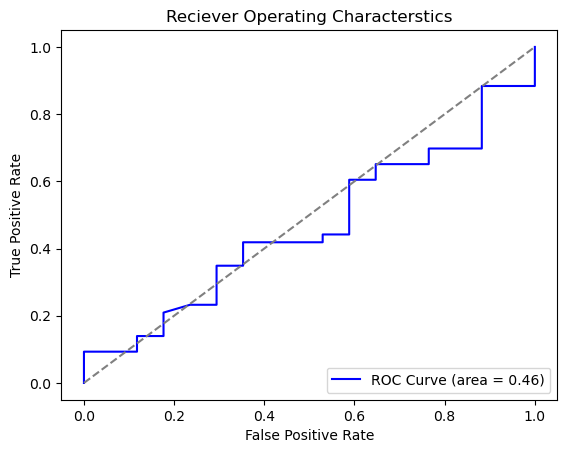

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_prod = model.predict_proba(x_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test,y_prod)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue',label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0,1],[0,1],color='gray',linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Reciever Operating Characterstics')
plt.legend(loc="lower right")
plt.show()

In [43]:
import joblib
joblib.dump(model, '03_risk_predict.ipynb')

['03_risk_predict.ipynb']